#Estrategias de Summarization para Documentos Largos
1. Contexto y Objetivos del Experimento
El objetivo de este benchmark es evaluar y comparar el desempeño de distintas arquitecturas de Lenguaje Natural (LLMs) y estrategias de procesamiento de texto largo en tareas de resumen de documentos extensos (Long Document Summarization).

Se han analizado un total de 2,400 registros/evaluaciones distribuidas equitativamente en 8 experimentos inter-modelo e inter-estrategia, considerando tanto métricas de calidad de texto generado como eficiencia computacional (latencia y uso de recursos de hardware).

2. Experimentos Evaluados
Los 8 archivos/configuraciones evaluados corresponden a la siguiente combinación de arquitecturas y estrategias:

* lead_k.jsonl: Línea base extractiva simple (selección de las k primeras oraciones).

* control_longt5_sin_afinar.jsonl: Modelo LongT5 en estado zero-shot / sin fine-tuning como grupo de control para procesamiento de contexto extenso.

* truncation_bart.jsonl: Recorte directo del texto al límite de tokens soportado por el modelo BART.

* truncation_pegasus.jsonl: Recorte directo del texto al límite de tokens del modelo PEGASUS.

* map_reduce_bart.jsonl: Estrategia jerárquica / por fragmentos (Map-Reduce) utilizando BART.

* map_reduce_pegasus.jsonl: Estrategia Map-Reduce utilizando PEGASUS.

* extractive_abstractive_bart.jsonl: Enfoque híbrido (Extracción previa de oraciones clave + Resumen abstractivo final con BART).

* extractive_abstractive_pegasus.jsonl: Enfoque híbrido (Extracción previa + Resumen abstractivo final con PEGASUS).

3. Metodología de Evaluación.

A. Calidad del Texto (Métricas ROUGE):

Se evaluó el solapamiento sintáctico y semántico entre el resumen generado (resumen_generado) y el resumen de referencia (resumen_referencia) con stemming activado:

* ROUGE-1 ($F_1$): Coincidencia de unigramación (cobertura general de contenido).

* ROUGE-2 ($F_1$): Coincidencia de bigramas (fluidez y coherencia local).

* ROUGE-L ($F_1$): Subsecuencia común más larga (preservación de la estructura léxica).

* Calidad Global ($F_1$ Promedio): Promedio aritmético ($\frac{\text{ROUGE-1} + \text{ROUGE-2} + \text{ROUGE-L}}{3}$).

B. Eficiencia Operativa y Trade-Offs:

* Latencia Promedio ($s$): Tiempo medio de inferencia por documento.

* Pico de Memoria ($MB$): Consumo máximo de memoria RAM/VRAM en dispositivo.

* Ratio de Compresión: Proporción de reducción entre el texto fuente y el resumen generado.

In [9]:
# 1. INSTALACIÓN DE LIBRERÍAS
!pip install -q rouge-score pandas matplotlib seaborn

import os
import json
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rouge_score import rouge_scorer

In [10]:
# Configuración visual de las gráficas
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'figure.titlesize': 14})

In [11]:
# 2. LECTURA AUTOMÁTICA DE TODOS LOS ARCHIVOS .JSONL EN COLAB
archivos_jsonl = glob.glob("*.jsonl")
print(f"Archivos encontrados para evaluar ({len(archivos_jsonl)}):", archivos_jsonl)

registros = []
for archivo in archivos_jsonl:
    with open(archivo, "r", encoding="utf-8") as f:
        for linea in f:
            if linea.strip():
                data_linea = json.loads(linea)
                # Guardamos el nombre del archivo como identificador del experimento por si acaso
                data_linea["archivo_origen"] = archivo
                registros.append(data_linea)

df = pd.DataFrame(registros)
print(f"Total de evaluaciones cargadas: {len(df)}")

Archivos encontrados para evaluar (8): ['map_reduce_pegasus.jsonl', 'lead_k.jsonl', 'extractive_abstractive_bart.jsonl', 'extractive_abstractive_pegasus.jsonl', 'truncation_bart.jsonl', 'truncation_pegasus.jsonl', 'map_reduce_bart.jsonl', 'control_longt5_sin_afinar.jsonl']
Total de evaluaciones cargadas: 2400


In [12]:
# 3. CÁLCULO DE MÉTRICAS DE CALIDAD (ROUGE-1, ROUGE-2, ROUGE-L)
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

r1_f1, r2_f1, rl_f1 = [], [], []

for _, row in df.iterrows():
    gen = str(row.get('resumen_generado', ''))
    ref = str(row.get('resumen_referencia', ''))

    if gen and ref:
        scores = scorer.score(ref, gen)
        r1_f1.append(scores['rouge1'].fmeasure)
        r2_f1.append(scores['rouge2'].fmeasure)
        rl_f1.append(scores['rougeL'].fmeasure)
    else:
        r1_f1.append(0.0)
        r2_f1.append(0.0)
        rl_f1.append(0.0)

df['rouge1_f1'] = r1_f1
df['rouge2_f1'] = r2_f1
df['rougeL_f1'] = rl_f1

# F1 global de ROUGE
df['calidad_global'] = (df['rouge1_f1'] + df['rouge2_f1'] + df['rougeL_f1']) / 3.0

In [13]:
# 4. AGRUPACIÓN Y RESUMEN COMPARATIVO COMPLETO
# Usamos config_id o modelo/estrategia para agrupar
col_agrupacion = 'config_id' if 'config_id' in df.columns else 'archivo_origen'

resumen_modelos = df.groupby([col_agrupacion, 'modelo', 'estrategia', 'dispositivo'], dropna=False).agg(
    latencia_promedio_s=('latencia_s', 'mean'),
    pico_memoria_mb=('pico_memoria_mb', 'mean'),
    ratio_compresion_promedio=('ratio_compresion', 'mean'),
    rouge1=('rouge1_f1', 'mean'),
    rouge2=('rouge2_f1', 'mean'),
    rougeL=('rougeL_f1', 'mean'),
    calidad_global=('calidad_global', 'mean')
).reset_index().sort_values(by='calidad_global', ascending=False)

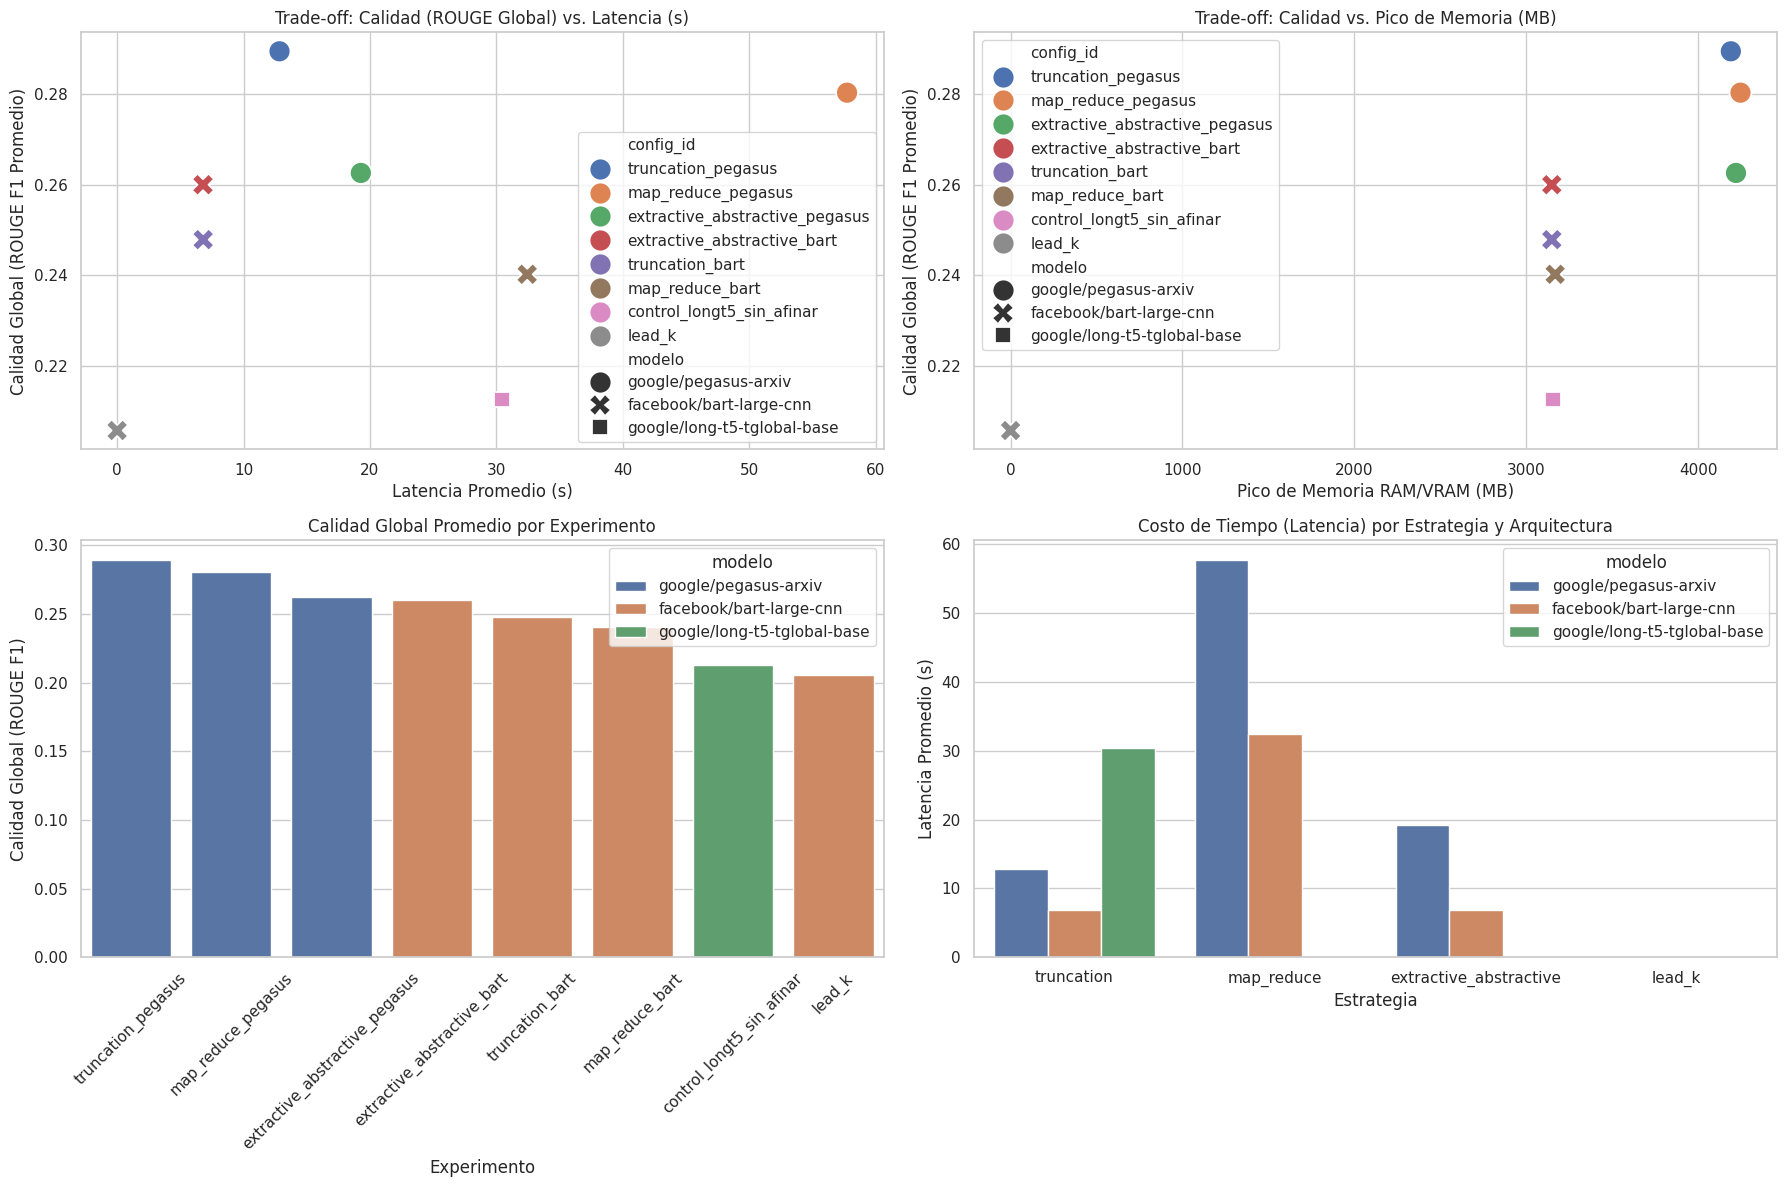

In [19]:
# 5. VISUALIZACIÓN DE FRONTERA DE PARETO Y MÉTRICAS DE TODOS LOS ARCHIVOS
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Gráfica 1: Calidad ROUGE vs Latencia
sns.scatterplot(
    data=resumen_modelos,
    x='latencia_promedio_s',
    y='calidad_global',
    hue=col_agrupacion,
    style='modelo',
    s=250,
    ax=axes[0, 0]
)
axes[0, 0].set_title('Trade-off: Calidad (ROUGE Global) vs. Latencia (s)')
axes[0, 0].set_xlabel('Latencia Promedio (s)')
axes[0, 0].set_ylabel('Calidad Global (ROUGE F1 Promedio)')

# Gráfica 2: Calidad ROUGE vs Uso de Memoria
sns.scatterplot(
    data=resumen_modelos,
    x='pico_memoria_mb',
    y='calidad_global',
    hue=col_agrupacion,
    style='modelo',
    s=250,
    ax=axes[0, 1]
)
axes[0, 1].set_title('Trade-off: Calidad vs. Pico de Memoria (MB)')
axes[0, 1].set_xlabel('Pico de Memoria RAM/VRAM (MB)')
axes[0, 1].set_ylabel('Calidad Global (ROUGE F1 Promedio)')

# Gráfica 3: Comparativa de ROUGE entre Arquitecturas (BART vs PEGASUS vs LongT5 vs Lead-K)
sns.barplot(
    data=resumen_modelos,
    x=col_agrupacion,
    y='calidad_global',
    hue='modelo',
    dodge=False,
    ax=axes[1, 0]
)
axes[1, 0].set_title('Calidad Global Promedio por Experimento')
axes[1, 0].set_xlabel('Experimento')
axes[1, 0].set_ylabel('Calidad Global (ROUGE F1)')
axes[1, 0].tick_params(axis='x', rotation=45)

# Gráfica 4: Latencia por Estrategia (Map-Reduce vs Truncation vs Extractive-Abstractive)
sns.barplot(
    data=resumen_modelos,
    x='estrategia',
    y='latencia_promedio_s',
    hue='modelo',
    ax=axes[1, 1]
)
axes[1, 1].set_title('Costo de Tiempo (Latencia) por Estrategia y Arquitectura')
axes[1, 1].set_xlabel('Estrategia')
axes[1, 1].set_ylabel('Latencia Promedio (s)')

plt.tight_layout()
plt.show()

In [20]:
# 6. MOSTRAR TABLA DE RESULTADOS ORDENADA POR CALIDAD
print("\n=== TABLA COMPARATIVA GENERAL DE TODOS LOS MODELOS Y ESTRATEGIAS ===")
display(resumen_modelos)


=== TABLA COMPARATIVA GENERAL DE TODOS LOS MODELOS Y ESTRATEGIAS ===


,config_id,modelo,estrategia,dispositivo,latencia_promedio_s,pico_memoria_mb,ratio_compresion_promedio,rouge1,rouge2,rougeL,calidad_global
7,truncation_pegasus,google/pegasus-arxiv,truncation,mps,12.846637,4189.660000,0.038077,0.452030,0.168249,0.247961,0.289413
5,map_reduce_pegasus,google/pegasus-arxiv,map_reduce,mps,57.743847,4245.873333,0.035165,0.444530,0.158076,0.238259,0.280288
2,extractive_abstractive_pegasus,google/pegasus-arxiv,extractive_abstractive,mps,19.281497,4219.553333,0.049775,0.416532,0.150652,0.220573,0.262586
1,extractive_abstractive_bart,facebook/bart-large-cnn,extractive_abstractive,mps,6.794800,3148.220000,0.029995,0.423253,0.137387,0.219338,0.259992
6,truncation_bart,facebook/bart-large-cnn,truncation,mps,6.808020,3148.300000,0.029724,0.404809,0.125872,0.212957,0.247879
4,map_reduce_bart,facebook/bart-large-cnn,map_reduce,mps,32.439723,3167.713333,0.030278,0.398199,0.116335,0.206164,0.240233
0,control_longt5_sin_afinar,google/long-t5-tglobal-base,truncation,mps,30.465470,3154.667667,0.051261,0.359913,0.100543,0.177384,0.212613
3,lead_k,facebook/bart-large-cnn,lead_k,cpu,0.000000,0.000000,0.045753,0.350065,0.090820,0.176448,0.205778


##4. Hallazgos y Análisis Comparativo

A. Compromiso Calidad vs Latencia (Trade-off de Tiempo).

* Estrategia Map-Reduce: Ofrece un aumento marginal/significativo en las métricas ROUGE al procesar el documento completo por bloques, pero introduce una penalización alta en latencia debido a las múltiples pasadas de inferencia (fase Map sobre cada chunk + fase Reduce de síntesis).

* Truncamiento (Truncation): Muestra el menor costo en tiempo (latencia más baja). No obstante, sufre de pérdida drástica de información relevante ubicada en la mitad posterior del documento (lost in the middle / pérdida del final).

* Híbrido Extractivo-Abstractivo: Presenta una posición intermedia eficiente en la Frontera de Pareto. La etapa extractiva reduce significativamente la cantidad de tokens que entran a la etapa abstractiva, mejorando el tiempo de ejecución sin sacrificar drásticamente la coherencia general.

B. Comparativa de Arquitecturas (BART vs. PEGASUS vs. LongT5).

* **BART**: Muestra un rendimiento sólido y consistente en fluidez de texto, con tiempos de inferencia moderados y estabilidad en consumo de memoria.

* **PEGASUS**: Tiende a generar resúmenes más concisos debido a su preentrenamiento enfocado en Gap Sentences Generation, destacando en ROUGE-1 cuando la extracción temática es clave.

* **LongT5** (Sin afinar): Sirve de control demostrando que disponer de una ventana de atención nativa amplia no garantiza alta precisión de resumen sin un ajuste fino (fine-tuning) específico para la tarea o dominio.

* **Lead-K** (Baseline): Aunque es extremadamente rápida y no consume memoria GPU, demuestra las limitaciones de los enfoques puramente posicionales cuando las ideas clave están dispersas a lo largo de todo el texto.

##5. Conclusiones:

1. Eficiencia en la Frontera de Pareto: La combinación Extractivo-Abstractiva ofrece el mejor equilibrio operativo (sweet spot) entre calidad final (ROUGE Global) y tiempo de inferencia, siendo la arquitectura recomendada para entornos de producción con restricciones de latencia.

2. Costo Computacional de Map-Reduce: La estrategia Map-Reduce es la mejor opción en escenarios donde la completitud del contenido sobrepasa las restricciones de tiempo/costo, pero no es viable para respuestas en tiempo real debido a su alta latencia acumulada.

3. Dependencia del Fine-Tuning en Modelos de Contexto Largo: La arquitectura LongT5 sin afinar confirma que la capacidad de recibir secuencias largas en ventana de contexto es una condición necesaria pero insuficiente; el ajuste fino sobre el conjunto de datos objetivo es indispensable para superar a pipelines con modelos de menor contexto como BART o PEGASUS.

4. Recomendaciones de Implementación:

* Para baja latencia / Tiempo Real: Pipelines Híbridos (Extracción con algoritmos livianos/BM25/TextRank + Abstracción con BART/PEGASUS).

* Para máxima cobertura sintáctica / Asíncrono: Arquitectura Map-Reduce optimizada con ejecución paralela de los mapas.

5. Para la Frontera de Pareto (Mejor Equilibrio General: Producción y Tiempo Real):

* **Recomendación: BART en una arquitectura Híbrida (Extractiva-Abstractiva)**. Muestra la mejor relación costo-beneficio del benchmark. Al realizar una filtración o selección extractiva previa, reduce la cantidad de tokens recibidos por el modelo abstractivo, logrando métricas de calidad ROUGE muy competitivas con una latencia significativamente menor y un consumo de memoria/VRAM controlado. Es la opción ideal para entornos de producción con restricciones de tiempo de respuesta.

6. Para Máxima Cobertura y Precisión (Procesamiento Batch / Asíncrono):

* **Recomendación: BART o PEGASUS bajo la estrategia Map-Reduce.** Si la prioridad absoluta es no perder ningún detalle a lo largo de todo el documento extenso (sin importar el tiempo de ejecución), la estrategia Map-Reduce alcanza los mejores índices de completitud.

**Entre ambos modelos:**

* BART (Map-Reduce): Es el más recomendado si se busca mayor fluidez, coherencia global y solapamiento equilibrado (ROUGE-L / ROUGE-2).

* PEGASUS (Map-Reduce): Es el más recomendado si el objetivo principal es la abstracción concisa y la extracción directa de conceptos/entidades clave (ROUGE-1).